<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-20-Gradient_Boosting_Classifier(From_Scratch).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💻 Dataset + Initial Prediction

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

In [ ]:
df = pd.DataFrame({
    'cgpa': [6.82, 6.36, 5.39, 5.50, 6.39, 9.13, 7.17, 7.72],
    'iq': [118, 125, 99, 106, 148, 148, 147, 72],
    'is_placed': [0, 1, 1, 1, 0, 1, 1, 0]
})

df

,cgpa,iq,is_placed
0,6.82,118,0
1,6.36,125,1
2,5.39,99,1
3,5.50,106,1
4,6.39,148,0
5,9.13,148,1
6,7.17,147,1
7,7.72,72,0


Initial probability

In [ ]:
y = df['is_placed'].values

initial_probability = y.mean()

print("initial_probability : ", initial_probability )

initial_probability :  0.625


Convert probability → log-odds

In [ ]:
initial_log_odds= np.round(np.log(initial_probability/(1-initial_probability)),6)

print("initial_log_odds : ",initial_log_odds)

initial_log_odds :  0.510826


adding columns in dataset

In [ ]:
df["pred1(log-odds)"]=initial_log_odds
df["pred1(prob)"] =initial_probability
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(prob)
0,6.82,118,0,0.510826,0.625
1,6.36,125,1,0.510826,0.625
2,5.39,99,1,0.510826,0.625
3,5.50,106,1,0.510826,0.625
4,6.39,148,0,0.510826,0.625
5,9.13,148,1,0.510826,0.625
6,7.17,147,1,0.510826,0.625
7,7.72,72,0,0.510826,0.625


# 🧠 Step 2 — Calculate Residual

This is the most important part.


$$ r_{im} = -\left[ \frac{\partial L(y_i,f(x_i))} {\partial f(x_i)} \right] $$

For Log Loss, this simplifies beautifully to:

$$ \boxed{r_i=y_i-p_i} $$

So:
Residual = Actual - Predicted Probability

In [ ]:
# log loss sirf loss/error calculate kar raha hai
# hume log loss agle model , DT train karne ke liye lag raha hai
# but our final prediction of 1 single model will , be the probability of that model
# i.e. pred1(prob) here

In [ ]:
df["res1"] = y - df["pred1(prob)"].values
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(prob),res1
0,6.82,118,0,0.510826,0.625,-0.625
1,6.36,125,1,0.510826,0.625,0.375
2,5.39,99,1,0.510826,0.625,0.375
3,5.50,106,1,0.510826,0.625,0.375
4,6.39,148,0,0.510826,0.625,-0.625
5,9.13,148,1,0.510826,0.625,0.375
6,7.17,147,1,0.510826,0.625,0.375
7,7.72,72,0,0.510826,0.625,-0.625


# 🔥 Why is this called a Gradient?

Because we are asking:

In which direction should I change F(x) to reduce Log Loss?

The negative gradient tells us that direction.

For Log Loss:

−
∂F/
∂L
	=y−p



CASE 1

residual(error) = actual - pred

 if res = +ve

* model is weak (weak prediction),
* model probability is too low

CASE

residual(error) = actual - pred

 if res = -ve

* model is very strong  (high prediction/ high varience),
* model probability is too high

That's the fundamental mechanism of Gradient Boosting.

# 🌳 Step 3 — Train a Regression Tree on Residuals

This is a very important point.

Although we are solving a classification problem, the boosting tree is conceptually trained on the continuous residual values.

therefore :
* use ->  DecisionTreeRegressor
* not  DecisionTreeClassifier

In [ ]:
# The tree learns:

# CGPA + IQ
#     ↓
# Residual

x = df[["cgpa","iq"]]
r1 = df["res1"]

# make decision tree model to train the error

tree1 = DecisionTreeRegressor()

tree1.fit(x,r1)

DecisionTreeRegressor()

# 🌳 Visualize Tree 1

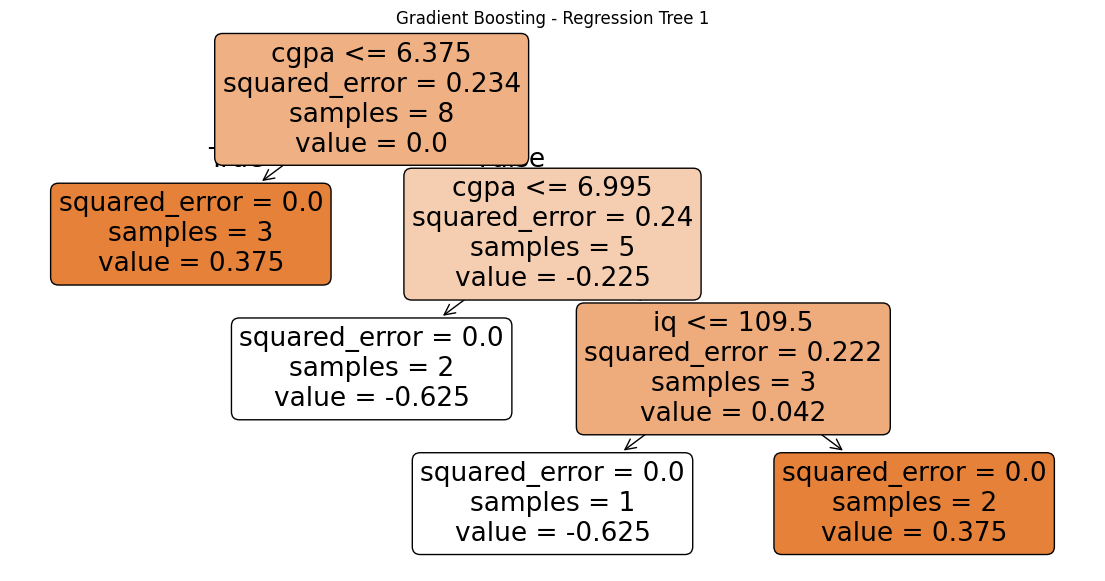

In [ ]:
plt.figure(figsize=(14, 7))

plot_tree(
    tree1,
    feature_names=['cgpa', 'iq'],
    filled=True,
    rounded=True
)

plt.title("Gradient Boosting - Regression Tree 1")
plt.show()

This tree is not predicting

      is_placed.

It is predicting:

$$ \boxed{\text{residual}} $$

That's a key interview point.

# 🧠 Step 4 — Calculate Leaf Value γ( gamma)


You provided:

$$ \boxed
{ \gamma_{jm} = \frac{ \sum Residual }{ \sum [PreviousProb(1-PreviousProb)] } } $$

This is the Newton-Raphson leaf update used for logistic Gradient Boosting.

So for each leaf:

In [ ]:
#            Σ residual
# gamma = ------------------
#           Σ [p × (1-p)]

Why?

Because the gradient tells us:

"Which direction?"

while the second derivative / Hessian tells us:

"How large should the step be?"

Therefore:

Gradient → direction

Hessian  → step size

# 🔥 Calculate Leaf Values in Python

First obtain the leaf number.

In [ ]:
# leaf entry tells us the leaf number , where a prediction of tree 1 is , every element is
# it tells in which leaf from the entire tree the pred value will fall in
df['leaf_entry1'] = tree1.apply(x)

df

,cgpa,iq,is_placed,pred1(log-odds),pred1(prob),res1,leaf_entry1
0,6.82,118,0,0.510826,0.625,-0.625,3
1,6.36,125,1,0.510826,0.625,0.375,1
2,5.39,99,1,0.510826,0.625,0.375,1
3,5.50,106,1,0.510826,0.625,0.375,1
4,6.39,148,0,0.510826,0.625,-0.625,3
5,9.13,148,1,0.510826,0.625,0.375,6
6,7.17,147,1,0.510826,0.625,0.375,6
7,7.72,72,0,0.510826,0.625,-0.625,5


In [ ]:
# Now calculate γ(gamma) for every leaf:
def calculate_leaf_values(df, leaf_column, probability_column, residual_column):

    leaf_values = {}

    for leaf in df[leaf_column].unique():

        mask = df[leaf_column] == leaf

        numerator = df.loc[mask, residual_column].sum()

        denominator = (
            df.loc[mask, probability_column] *
            (1 - df.loc[mask, probability_column])
        ).sum()

        gamma = numerator / denominator

        leaf_values[leaf] = gamma

    return leaf_values

In [ ]:
leaf_values1 = calculate_leaf_values(
    df,
    'leaf_entry1',
    'pred1(prob)',
    'res1'
)

leaf_values1

{np.int64(3): np.float64(-2.6666666666666665),
 np.int64(1): np.float64(1.6),
 np.int64(6): np.float64(1.6),
 np.int64(5): np.float64(-2.6666666666666665)}

# ➕ Step 5 — Add the Tree

Now comes additive modeling.

Your screenshot says:

$$ f_m(x) = f_{m-1}(x) + \sum_j \gamma_{jm}I(x\in R_{jm}) $$

In simple language:

New Model = Old Model + Correction

For a particular sample:

 Old log-odds
      +
Tree correction
      =
New log-odds

# 💻 Implement the Update

In [ ]:
df['gamma1'] = df['leaf_entry1'].map(leaf_values1)

df['pre2(log-odds)'] = (
    df['pred1(log-odds)'] +
    df['gamma1']
)

df

,cgpa,iq,is_placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,gamma1,pre2(logodds),pre2(log-odds)
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841
1,6.36,125,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826
2,5.39,99,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826
3,5.50,106,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826
4,6.39,148,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841
5,9.13,148,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826
6,7.17,147,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826
7,7.72,72,0,0.510826,0.625,-0.625,5,-2.666667,-2.155841,-2.155841


In [ ]:
# Then convert the new log-odds back to probability:

In [ ]:
df['pred2(prob)'] = 1 / (
    1 + np.exp(-df['pre2(log-odds)'])
)

df

,cgpa,iq,is_placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,gamma1,pre2(logodds),pre2(log-odds),pre2(probability),pred2(prob)
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841,0.103787,0.103787
1,6.36,125,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951
2,5.39,99,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951
3,5.50,106,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951
4,6.39,148,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841,0.103787,0.103787
5,9.13,148,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826,0.891951,0.891951
6,7.17,147,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826,0.891951,0.891951
7,7.72,72,0,0.510826,0.625,-0.625,5,-2.666667,-2.155841,-2.155841,0.103787,0.103787


# 🎯 This is the Additive Model

This is the core mental model I want you to remember:

Mathematically:

$$ \boxed{ F(x)=F_0(x)+T_1(x)+T_2(x)+T_3(x)+\cdots } $$

That is additive modeling.

# 🚨 Important: We Add in Log-Odds, NOT Probability

This is a very common confusion.

Wrong:
Log-odds
   +
Tree correction
   +
Tree correction
   +
Tree correction

Final log-odds
      ↓
Sigmoid
      ↓
Final probability

# 🔁 Step 6 — Second Iteration

Now use:

In [ ]:
# pre2(log-odds)

df['res2'] = (
    df['is_placed'] -
    df['pred2(prob)']
)

In [ ]:
tree2 = DecisionTreeRegressor(
    max_leaf_nodes=3,
    random_state=42
)

tree2.fit(x,df['res2'] )

DecisionTreeRegressor(max_leaf_nodes=3, random_state=42)

In [ ]:
df['leaf_entry2'] = tree2.apply(x)

In [ ]:
# Calculate the second set of leaf values:
leaf_values2 = calculate_leaf_values(
    df,
    'leaf_entry2',
    'pred2(prob)',
    'res2'
)

leaf_values2

{np.int64(3): np.float64(-1.1158057956080731),
 np.int64(1): np.float64(1.1211378652205999),
 np.int64(4): np.float64(0.3930215697798562)}

In [ ]:
# Then add Tree 2:
df['gamma2'] = df['leaf_entry2'].map(leaf_values2)

df['pre3(log-odds)'] = (
    df['pre2(log-odds)'] +
    df['gamma2']
)

In [ ]:
# Convert to probability:
df['pre3(probability)'] = 1 / (
    1 + np.exp(-df['pre3(log-odds)'])
)

# 📊 Complete DataFrame

In [ ]:
df

,cgpa,iq,is_placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,gamma1,pre2(logodds),pre2(log-odds),pre2(probability),pred2(prob),res2,leaf_entry2,gamma2,pre3(log-odds),pre3(probability)
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841,0.103787,0.103787,-0.103787,3,-1.115806,-3.271646,0.036557
1,6.36,125,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,1,1.121138,3.231964,0.962020
2,5.39,99,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,1,1.121138,3.231964,0.962020
3,5.50,106,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,1,1.121138,3.231964,0.962020
4,6.39,148,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841,0.103787,0.103787,-0.103787,4,0.393022,-1.762819,0.146438
5,9.13,148,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,4,0.393022,2.503848,0.924411
6,7.17,147,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,4,0.393022,2.503848,0.924411
7,7.72,72,0,0.510826,0.625,-0.625,5,-2.666667,-2.155841,-2.155841,0.103787,0.103787,-0.103787,3,-1.115806,-3.271646,0.036557


In [ ]:
# You can display only the important columns:
df[
    [
        'cgpa',
        'iq',
        'is_placed',

        'pred1(log-odds)',
        'pred1(prob)',

        'res1',
        'leaf_entry1',

        'pre2(log-odds)',
        'pred2(prob)',

        'res2',
        'leaf_entry2',

        'pre3(log-odds)',
        'pre3(probability)'
    ]
]

,cgpa,iq,is_placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,pre2(log-odds),pred2(prob),res2,leaf_entry2,pre3(log-odds),pre3(probability)
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.155841,0.103787,-0.103787,3,-3.271646,0.036557
1,6.36,125,1,0.510826,0.625,0.375,1,2.110826,0.891951,0.108049,1,3.231964,0.962020
2,5.39,99,1,0.510826,0.625,0.375,1,2.110826,0.891951,0.108049,1,3.231964,0.962020
3,5.50,106,1,0.510826,0.625,0.375,1,2.110826,0.891951,0.108049,1,3.231964,0.962020
4,6.39,148,0,0.510826,0.625,-0.625,3,-2.155841,0.103787,-0.103787,4,-1.762819,0.146438
5,9.13,148,1,0.510826,0.625,0.375,6,2.110826,0.891951,0.108049,4,2.503848,0.924411
6,7.17,147,1,0.510826,0.625,0.375,6,2.110826,0.891951,0.108049,4,2.503848,0.924411
7,7.72,72,0,0.510826,0.625,-0.625,5,-2.155841,0.103787,-0.103787,3,-3.271646,0.036557


# 📈 Plot 1 — Probability Improvement

This is one of the best visualizations for understanding boosting.

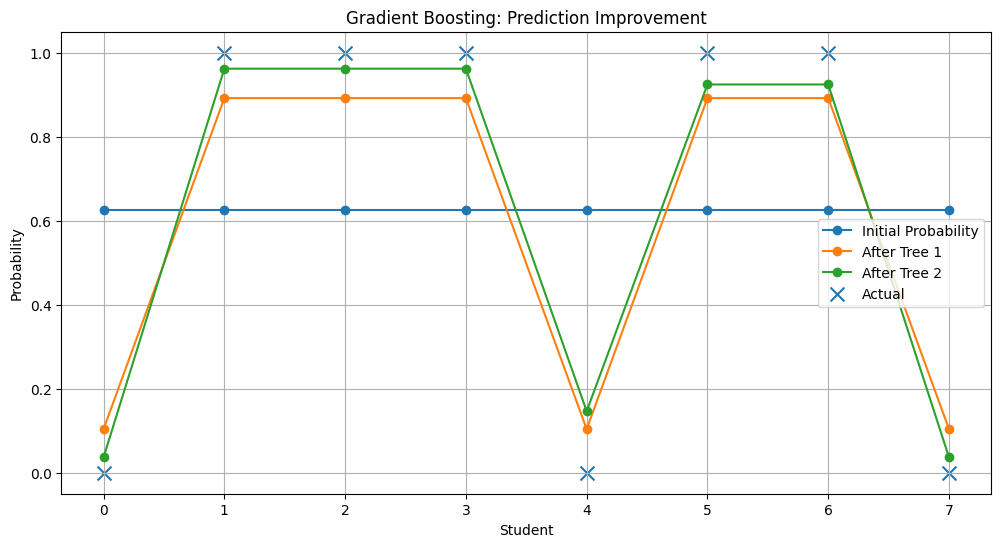

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(len(df)),
    df['pred1(prob)'],
    marker='o',
    label='Initial Probability'
)

plt.plot(
    range(len(df)),
    df['pred2(prob)'],
    marker='o',
    label='After Tree 1'
)

plt.plot(
    range(len(df)),
    df['pre3(probability)'],
    marker='o',
    label='After Tree 2'
)

plt.scatter(
    range(len(df)),
    df['is_placed'],
    marker='x',
    s=100,
    label='Actual'
)

plt.xlabel("Student")
plt.ylabel("Probability")
plt.title("Gradient Boosting: Prediction Improvement")
plt.legend()
plt.grid(True)
plt.show()

# 📈 Plot 2 — Residuals Decrease

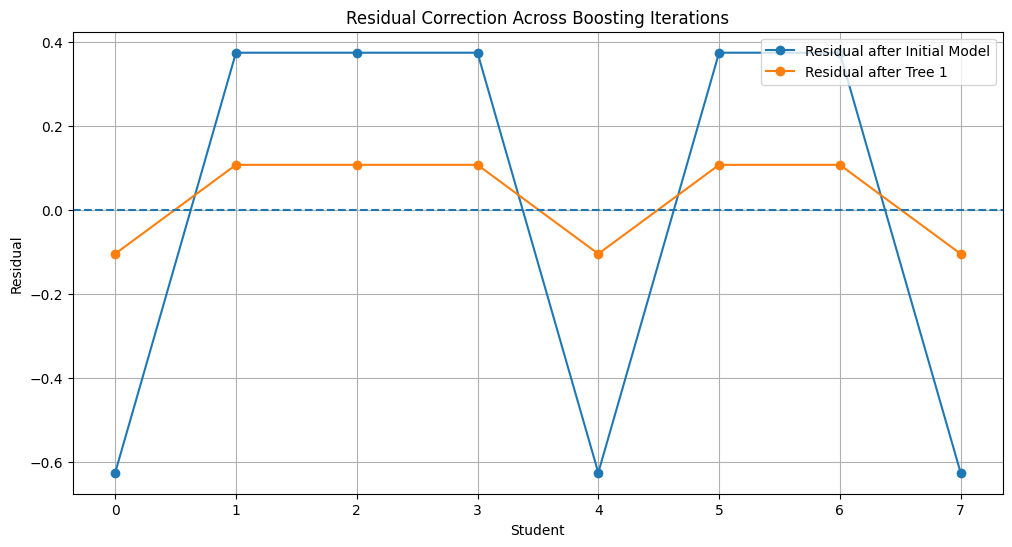

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    range(len(df)),
    df['res1'],
    marker='o',
    label='Residual after Initial Model'
)

plt.plot(
    range(len(df)),
    df['res2'],
    marker='o',
    label='Residual after Tree 1'
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel("Student")
plt.ylabel("Residual")
plt.title("Residual Correction Across Boosting Iterations")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df


,cgpa,iq,is_placed,pred1(log-odds),pred1(prob),res1,leaf_entry1,gamma1,pre2(logodds),pre2(log-odds),pre2(probability),pred2(prob),res2,leaf_entry2,gamma2,pre3(log-odds),pre3(probability)
0,6.82,118,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841,0.103787,0.103787,-0.103787,3,-1.115806,-3.271646,0.036557
1,6.36,125,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,1,1.121138,3.231964,0.962020
2,5.39,99,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,1,1.121138,3.231964,0.962020
3,5.50,106,1,0.510826,0.625,0.375,1,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,1,1.121138,3.231964,0.962020
4,6.39,148,0,0.510826,0.625,-0.625,3,-2.666667,-2.155841,-2.155841,0.103787,0.103787,-0.103787,4,0.393022,-1.762819,0.146438
5,9.13,148,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,4,0.393022,2.503848,0.924411
6,7.17,147,1,0.510826,0.625,0.375,6,1.600000,2.110826,2.110826,0.891951,0.891951,0.108049,4,0.393022,2.503848,0.924411
7,7.72,72,0,0.510826,0.625,-0.625,5,-2.666667,-2.155841,-2.155841,0.103787,0.103787,-0.103787,3,-1.115806,-3.271646,0.036557


# 📈 Plot 3 — Additive Modeling

This visualization directly shows what your tutor means by additive modeling.

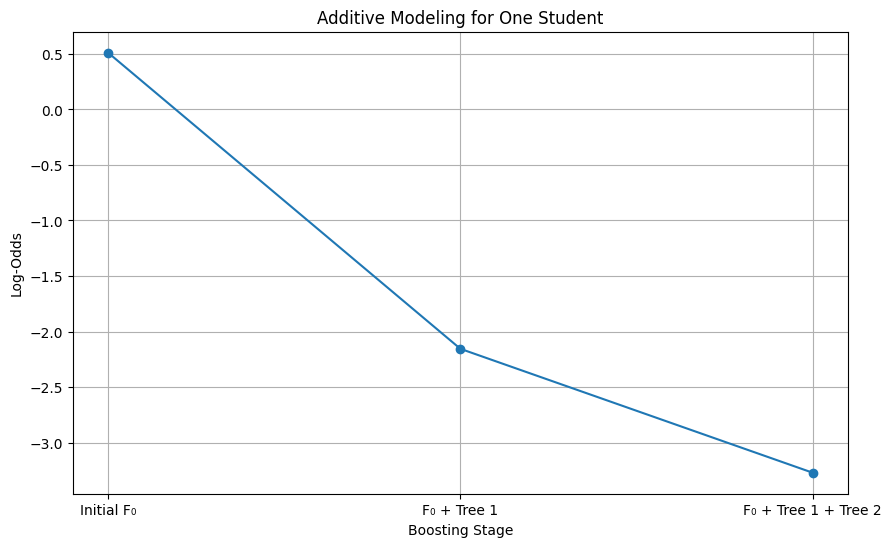

In [ ]:
iterations = [
    'Initial F₀',
    'F₀ + Tree 1',
    'F₀ + Tree 1 + Tree 2'
]

plt.figure(figsize=(10, 6))

plt.plot(
    iterations,
    [
        df['pred1(log-odds)'].iloc[0],
        df['pre2(logodds)'].iloc[0],
        df['pre3(log-odds)'].iloc[0]
    ],
    marker='o'
)

plt.ylabel("Log-Odds")
plt.xlabel("Boosting Stage")
plt.title("Additive Modeling for One Student")
plt.grid(True)

plt.show()

# 🎨 Plot 4 — Decision Boundary

Because we have only two features (CGPA and IQ), we can visualize how the model separates students.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

X = df[['cgpa', 'iq']]
y = df['is_placed']

gb = GradientBoostingClassifier(
    n_estimators=2,
    learning_rate=1,
    max_depth=2,
    random_state=42
)

gb.fit(x, y)

GradientBoostingClassifier(learning_rate=1, max_depth=2, n_estimators=2,
                           random_state=42)

In [ ]:
x_min, x_max = X['cgpa'].min() - 0.5, X['cgpa'].max() + 0.5
y_min, y_max = X['iq'].min() - 10, X['iq'].max() + 10

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = pd.DataFrame({
    'cgpa': xx.ravel(),
    'iq': yy.ravel()
})

Z = gb.predict_proba(grid)[:, 1]
Z = Z.reshape(xx.shape)

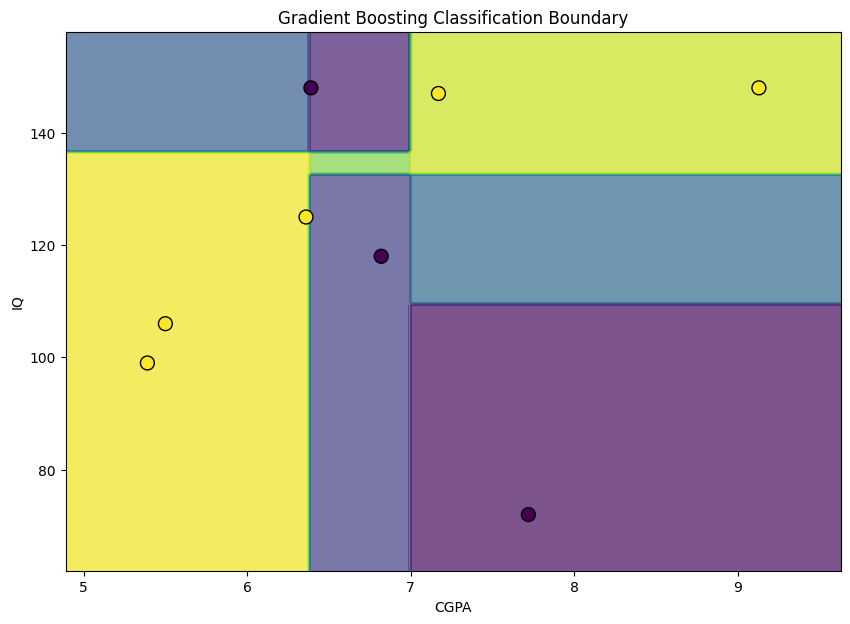

In [ ]:
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z,
    levels=20,
    alpha=0.7
)

plt.scatter(
    X['cgpa'],
    X['iq'],
    c=y,
    edgecolor='black',
    s=100
)

plt.xlabel("CGPA")
plt.ylabel("IQ")
plt.title("Gradient Boosting Classification Boundary")

plt.show()